# 02 – LPT lightcone construction

In this notebook we build a simple LPT-based "lightcone" using the public
`fwd_model_tools` API. The main steps are:

1. Draw Gaussian initial conditions on a 3D mesh.
2. Compute a set of scale factors along the line-of-sight using
   `compute_lpt_lightcone_scale_factors`.
3. Run LPT once with this array of scale factors.
4. Paint the resulting particle displacements to 3D and 2D density maps.

This is an **LPT-only** lightcone construction meant for pedagogical purposes
and small CPU runs; it is not the spherical lightcone used in the production
lensing examples.


## Imports & configuration
We configure JAX to run on CPU, import the main dependencies, and set up a
moderate mesh/box size so the notebook executes comfortably on a laptop.


In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import numpy as np

from fwd_model_tools import (
    FieldStatus,
    ParticleField,
    FlatDensity,
    SphericalDensity,
    gaussian_initial_conditions,
    lpt,
    compute_lpt_lightcone_scale_factors,
    Planck18,
)

mesh_size = (128, 128, 64)
box_size = (500.0, 500.0, 500.0)
observer_position = (0.5, 0.5, 0.5)


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Gaussian initial conditions for the lightcone
We draw a single realization of Gaussian initial conditions on a 3D mesh.
This field carries both flat-sky (`flatsky_npix`) and spherical (`nside`)
metadata that define the geometry used for projections.


In [2]:
key = jax.random.PRNGKey(42)
cosmo = Planck18()

gaussian_field = gaussian_initial_conditions(
    key=key,
    mesh_size=mesh_size,
    box_size=box_size,
    cosmo=cosmo,
    observer_position=observer_position,
    flatsky_npix=(128, 128),
    nside=64,
)

print("Initial field:", gaussian_field)
print(f"Status: {gaussian_field.status} (expected {FieldStatus.INITIAL_FIELD})")
print(f"Array shape: {gaussian_field.array.shape}")
print(f"Max comoving radius: {gaussian_field.max_comoving_radius:.2f} Mpc/h")


Initial field: DensityField(array=Array(128, 128, 64), mesh_size=(128, 128, 64), box_size=(500.0, 500.0, 500.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD (expected FieldStatus.INITIAL_FIELD)
Array shape: (128, 128, 64)
Max comoving radius: 250.00 Mpc/h


## Scale factors along the line of sight
We now compute scale factors associated with planes along the line-of-sight
using `compute_lpt_lightcone_scale_factors`. This returns one scale factor per
radial plane; we will feed the full array into a single batched LPT call.


In [3]:
a_all = compute_lpt_lightcone_scale_factors(cosmo, gaussian_field)
z_all = jc.utils.a2z(a_all)

print(f"Total number of radial planes: {a_all.size}")
print("First five (a, z):")
for ai, zi in zip(a_all[:5], z_all[:5]):
    print(f"  a={ai:.4f}, z={zi:.3f}")


Total number of radial planes: 64
First five (a, z):
  a=0.8528, z=0.173
  a=0.8548, z=0.170
  a=0.8568, z=0.167
  a=0.8588, z=0.164
  a=0.8608, z=0.162


## Batched LPT for the lightcone
We call `lpt` once with the full array of scale factors. In this lightcone
mode, the function returns a `FlatDensity` stack with one (ny, nx) map per
radial plane, plus a `ParticleField` carrying the underlying displacements
and momenta on the 3D mesh.


In [4]:
dx_lightcone, p_lightcone = lpt(
    cosmo=cosmo,
    initial_field=gaussian_field,
    a=a_all,
    order=1,
)

print("Flat lightcone stack:", dx_lightcone)
print(f"  Status: {dx_lightcone.status} (expected lightcone)")
print(f"  Array shape: {dx_lightcone.array.shape}  # (n_planes, ny, nx)")
print(
    "  Plane centers (comoving) shape:",
    jnp.atleast_1d(dx_lightcone.scale_factors).shape,
)


shape of initial force: (128, 128, 64, 3)
growth factor shape: (1, 1, 64, 1)
Flat lightcone stack: FlatDensity(array=Array(64, 128, 128), mesh_size=(128, 128, 64), box_size=(500.0, 500.0, 500.0), status=lightcone, scale_factors_shape=(64,))
  Status: DensityStatus.LIGHTCONE (expected lightcone)
  Array shape: (64, 128, 128)  # (n_planes, ny, nx)
  Plane centers (comoving) shape: (64,)


## Flat-sky lightcone stack
The flat-sky lightcone returned by `lpt` is a `FlatDensity` stack with one
map per radial plane. We can inspect its shape and visualize a few planes
using the `show` helper.


Flat lightcone stack shape: (64, 128, 128)


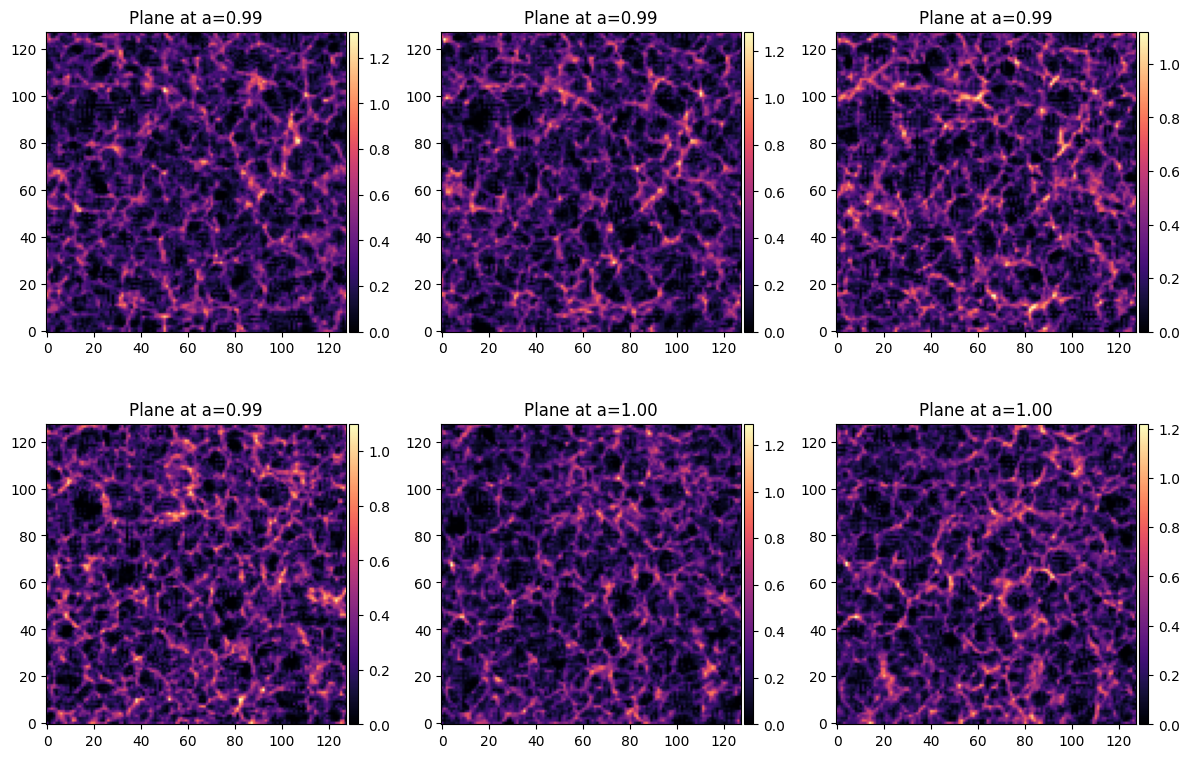

In [6]:
print("Flat lightcone stack shape:", dx_lightcone.array.shape)

# Visualize the first three planes in the stack
dx_lightcone[-6:].show(
    titles=[f"Plane at a={a:.2f}" for a in dx_lightcone.scale_factors[-6:]],
    figsize=(12, 8),
)


## Summary and next steps

In this notebook we:
- sampled Gaussian initial conditions on a 3D mesh,
- computed a set of scale factors along the line-of-sight,
- ran LPT once with this array to build an LPT-based lightcone,
- painted the result into 3D and 2D density maps,
- and demonstrated a simple spherical projection.

In Notebook 04 we will use lightcones (typically built via more specialized
helpers) as inputs to a Born-lensing pipeline that produces convergence maps
and power spectra.
